# Práctica — Clase 15: Tipos de Gráficos

> Dataset: `sensores.csv` (el mismo de la clase — temperatura, presión, consumo_kwh, producción, eficiencia, registrados hora a hora)

Los ejercicios están planteados como pedidos reales que podrías recibir en un trabajo. No vienen con el código resuelto — vienen con el problema que hay que resolver, como en la vida real. Usa lo que vimos hoy (líneas, barras, histograma, scatter, mapa de calor) y lo que ya sabías de personalización de gráficos.


---

## Ejercicio 1 — El reporte semanal para el jefe de planta

Tu jefe te escribe: *"Necesito ver cómo viene la producción esta semana, envíame algo simple que pueda mirar en 5 segundos."*

Crea un gráfico de líneas mostrando la producción a lo largo del dataset. Ponle título, nombre a los ejes, y asegúrate de que el eje Y no sea engañoso sobre el tamaño real de las variaciones.

**Pistas:**
- Piensa si conviene que el eje Y comience en 0 o no, según lo que quieras comunicarle a tu jefe.
- `ax.set_xlabel()`, `ax.set_ylabel()`, `ax.set_title()`.



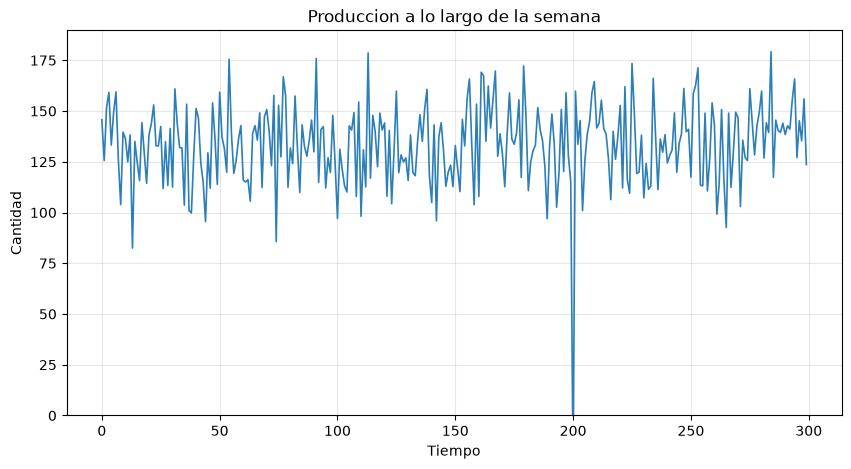

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("sensores.csv")

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(df.index, df["produccion"], color="#2c7fb8", linewidth=1.2)
ax.set_title("Produccion a lo largo de la semana")
ax.set_xlabel("Tiempo")
ax.set_ylabel("Cantidad")
ax.set_ylim(0)
ax.grid(alpha=0.3)
plt.show()

## Ejercicio 2 — Algo no cierra en el sensor de temperatura

Un compañero de mantenimiento te dice: *"Creo que un sensor de temperatura funcionó mal en algún momento, pero no sé cuándo. ¿Me puedes confirmar?"*

Grafica la temperatura a lo largo de todo el dataset y comenta en qué zona aproximada del gráfico ves algo raro. No hace falta calcular nada — solo observar.

**Pistas:**
- Un gráfico de líneas te muestra los saltos que no tienen continuidad con lo anterior ni con lo siguiente.
- Si el salto es difícil de ver por la escala del eje Y, prueba ajustando `set_ylim()`.

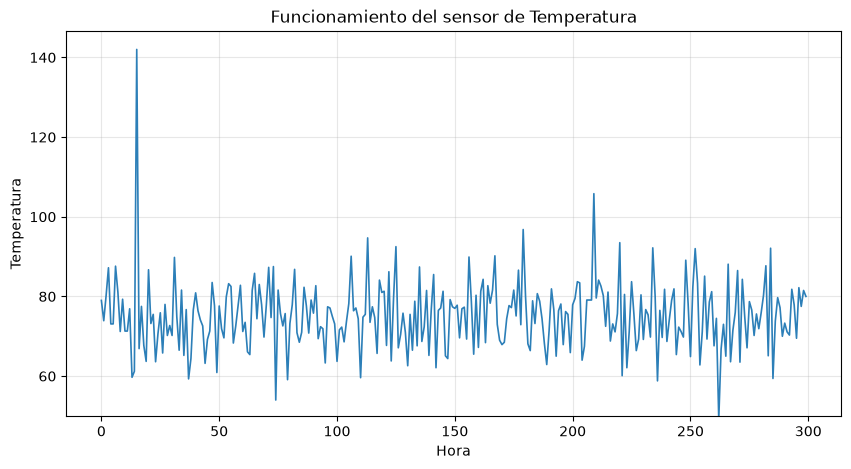

In [10]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(df.index, df["temperatura"], color="#2c7fb8", linewidth=1.2)
ax.set_title("Funcionamiento del sensor de Temperatura")
ax.set_xlabel("Hora")
ax.set_ylabel("Temperatura")
ax.set_ylim(50)
ax.grid(alpha=0.3)
plt.show()

## Ejercicio 3 — Comparar turnos para el área de RRHH

RRHH quiere saber si conviene reforzar personal en algún turno según el consumo eléctrico que maneja cada uno (más consumo = más carga operativa).

1. Crea una columna `turno` a partir de la hora del día (puedes usar `df.index % 24` y `pd.cut()`, como en la clase).
2. Calculá el consumo promedio por turno.
3. Grafícalo en barras, ordenado de mayor a menor.

**Pistas:**
- Recuerda: el eje Y de las barras siempre comienza en 0.
- `.groupby("turno")["consumo_kwh"].mean().sort_values(ascending=False)`

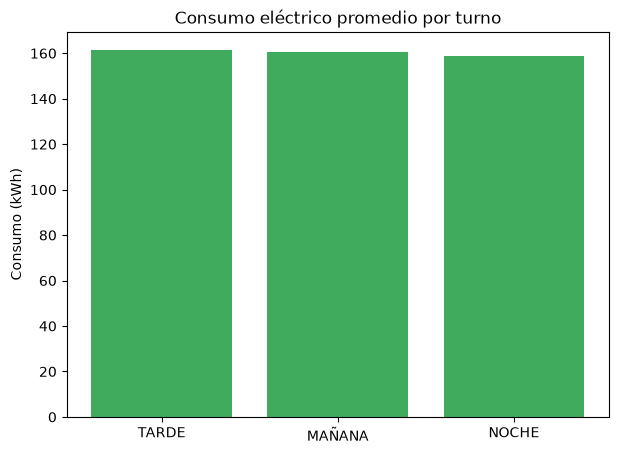

In [14]:
df["hora_del_dia"] = df.index % 24
df["turno"] = pd.cut (
    df["hora_del_dia"],
    bins=[1, 7, 15, 23],
    labels = ["NOCHE", "MAÑANA", "TARDE"]
)

consumo_por_turno = df.groupby("turno", observed=True)["consumo_kwh"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(consumo_por_turno.index, consumo_por_turno.values, color="#41ab5d")
ax.set_title("Consumo eléctrico promedio por turno")
ax.set_ylabel("Consumo (kWh)")
plt.show()

## Ejercicio 4 — Barras agrupadas: primera mitad del período vs. segunda mitad

Tu jefe ahora pregunta: *"¿La segunda mitad del período que registramos consumió más o menos que la primera, turno por turno?"*

Divide el dataset en dos mitades (usando el índice), calcula el consumo promedio por turno en cada mitad, y muéstralo con barras agrupadas (una al lado de la otra) para poder comparar turno por turno.

**Pistas:**
- `df.iloc[:150]` y `df.iloc[150:]` para partir el dataset.
- Repasa el ejemplo de barras agrupadas con `x - ancho/2` y `x + ancho/2` que vimos en una clase anterior de gráficos.


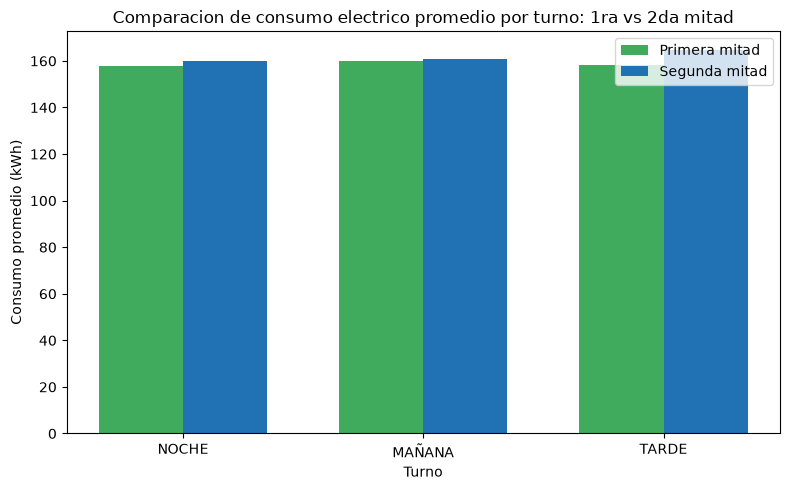

In [19]:
df["hora_del_dia"] = df.index % 24
df["turno"] = pd.cut (
    df["hora_del_dia"],
    bins=[1, 7, 15, 23],
    labels = ["NOCHE", "MAÑANA", "TARDE"]
)

primera_mitad = df.iloc[:150]
segunda_mitad = df.iloc[150:]

consumo_primera = primera_mitad.groupby("turno", observed= True)["consumo_kwh"].mean()
consumo_segunda = segunda_mitad.groupby("turno", observed=True)["consumo_kwh"].mean()

turnos = ["NOCHE", "MAÑANA", "TARDE"]
x = np.arange(len(turnos))  # Posiciones de las categorías en el eje X
ancho = (
    0.35  # Ancho de las barras (la suma de ambos anchos debe ser menor a 1.0)
)

fig, ax = plt.subplots(figsize=(8, 5))

barras1 = ax.bar(
    x - ancho / 2,
    [consumo_primera.get(t, 0) for t in turnos],
    ancho,
    label="Primera mitad",
    color="#41ab5d",
)
barras2 = ax.bar(
    x + ancho / 2,
    [consumo_segunda.get(t, 0) for t in turnos],
    ancho,
    label="Segunda mitad",
    color="#2171b5",
)

ax.set_title("Comparacion de consumo electrico promedio por turno: 1ra vs 2da mitad")
ax.set_ylabel("Consumo promedio (kWh)")
ax.set_xlabel("Turno")
ax.set_xticks(x)
ax.set_xticklabels(turnos)
ax.legend()

# Ajustes visuales
plt.tight_layout()
plt.show()

## Ejercicio 5 — ¿Los datos de producción son "normales"?

Antes de calcular cualquier estadística sobre la producción, tu supervisor te pide confirmar visualmente si los datos se comportan como una campana (distribución normal) o si hay algo inusual.

1. Grafica el histograma de `produccion` con `bins="fd"`.
2. Observa si la forma es simétrica, si está sesgada hacia algún lado, o si hay algo fuera de lugar.
3. Escribe, en un comentario dentro del código, qué observas.

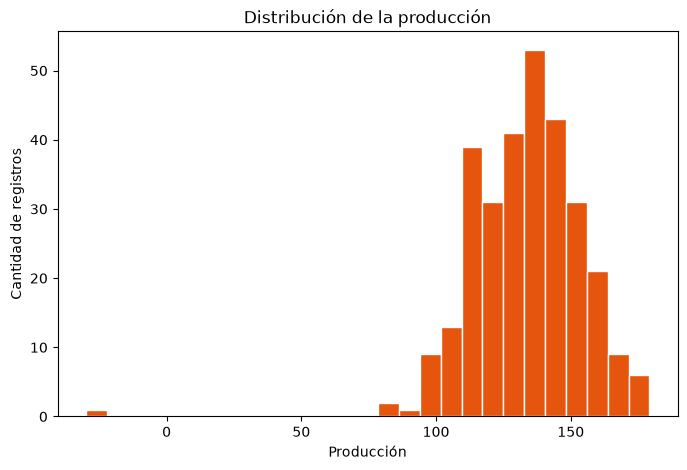

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["produccion"], bins="fd", color="#e6550d", edgecolor="white")
ax.set_title("Distribución de la producción")
ax.set_xlabel("Producción")
ax.set_ylabel("Cantidad de registros")
plt.show()


## Ejercicio 6 — Bins a prueba

Un compañero de otro equipo te envía un histograma con `bins=3` de la variable `eficiencia` y te dice que "los datos parecen bastante parejos, sin outliers".

Recrea ese histograma con `bins=3`, y después compáralo con el mismo histograma usando `bins="fd"`. ¿Tu compañero tenía razón? Escribe una conclusión corta.

**Pistas:**
- Puedes usar `plt.subplots(1, 2, figsize=(12, 4))` para mostrar los dos histogramas uno al lado del otro y comparar de un vistazo.


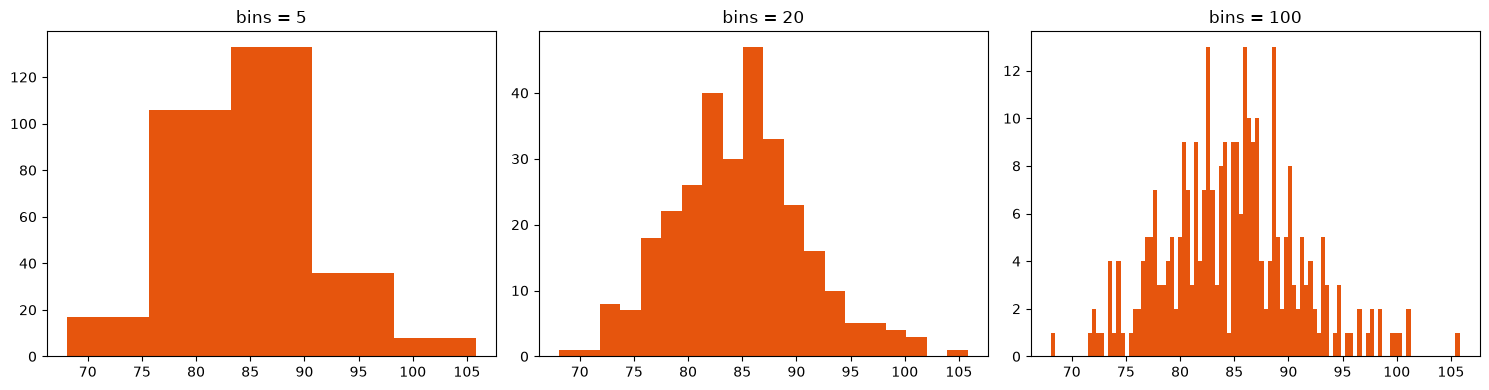

In [30]:
fig, ejes = plt.subplots(1, 3, figsize=(15, 4))

for eje, cantidad_bins in zip(ejes, [5, 20, 100]):
    eje.hist(df["eficiencia"], bins=cantidad_bins, color="#e6550d")
    eje.set_title(f"bins = {cantidad_bins}")


plt.tight_layout()
plt.show()


## Ejercicio 7 — ¿La presión depende de la temperatura?

El equipo de ingeniería quiere saber si hay una relación entre temperatura y presión, para ajustar los límites de seguridad de la planta.

1. Haz un scatter de `temperatura` (eje X) contra `presion` (eje Y).
2. A simple vista, ¿te parece que hay una relación lineal, o los puntos están dispersos sin patrón?
3. Marca con un color distinto (puedes graficar ese punto aparte, encima del scatter) el punto que corresponde al sensor defectuoso que encontraste en el Ejercicio 2.

**Pistas:**
- Para resaltar un punto puntual: `ax.scatter(df.loc[15, "temperatura"], df.loc[15, "presion"], color="red", s=100, label="Sensor defectuoso")` (ajusta el índice según lo que encontraste).


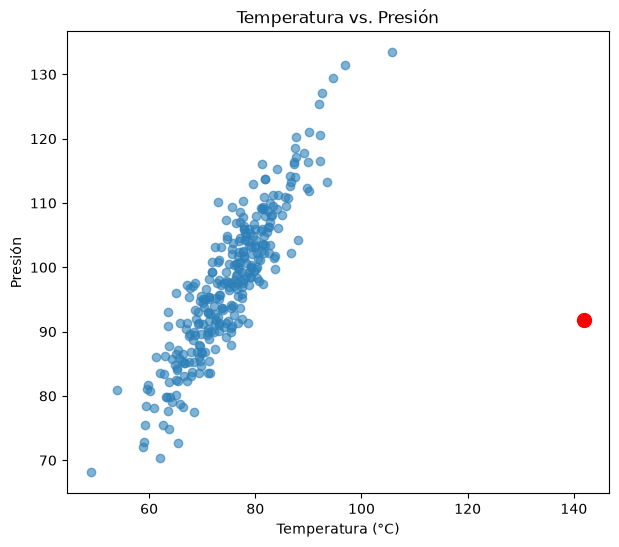

In [32]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df["temperatura"], df["presion"], alpha=0.6, color="#2c7fb8")
ax.set_xlabel("Temperatura (°C)")
ax.set_ylabel("Presión")
ax.set_title("Temperatura vs. Presión")
ax.scatter(df.loc[15, "temperatura"], df.loc[15, "presion"], color="red", s=100, label="Sensor defectuoso")
plt.show()

## Ejercicio 8 — Eficiencia según temperatura y consumo, todo junto

El gerente de planta te pide un solo gráfico que muestre, para cada registro: la temperatura, el consumo y la eficiencia — las tres variables a la vez.

Haz un scatter de `temperatura` vs. `consumo_kwh`, coloreando cada punto según su `eficiencia` (con `c=` y una `colorbar`).

**Pistas:**
- `cmap="viridis"` es una buena opción por defecto.
- No olvides `fig.colorbar()` para que se entienda qué representa el color.


/tmp/ipykernel_28723/856368581.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(df["temperatura"], df["consumo_kwh"], df["eficiencia"], cmap="viridis", alpha=0.6)


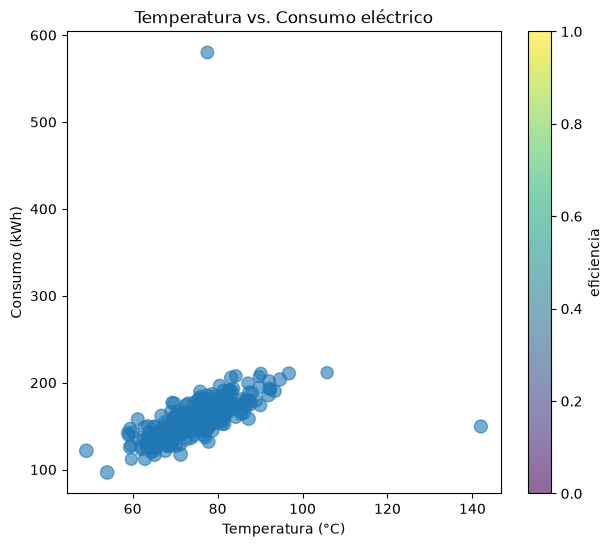

In [37]:
fig, ax = plt.subplots(figsize=(7, 6))

sc = ax.scatter(df["temperatura"], df["consumo_kwh"], df["eficiencia"], cmap="viridis", alpha=0.6)

ax.set_xlabel("Temperatura (°C)")
ax.set_ylabel("Consumo (kWh)")
ax.set_title("Temperatura vs. Consumo eléctrico")

fig.colorbar(sc, ax=ax, label="eficiencia")
plt.show()

## Ejercicio 9 — El panorama completo: matriz de correlación

Antes de armar cualquier modelo o reporte más elaborado, es buena práctica mirar cómo se relacionan todas las variables numéricas entre sí.

Crea un mapa de calor con la matriz de correlación de las cinco columnas numéricas del dataset (`temperatura`, `presion`, `consumo_kwh`, `produccion`, `eficiencia`), con los valores numéricos escritos dentro de cada celda.

**Pistas:**
- `df[columnas].corr()`, `ax.imshow()`, `cmap="coolwarm"`, `vmin=-1, vmax=1`.
- Repasa el bloque de "Todo junto" de la clase si te atoras con el `for` que escribe los números en cada celda.


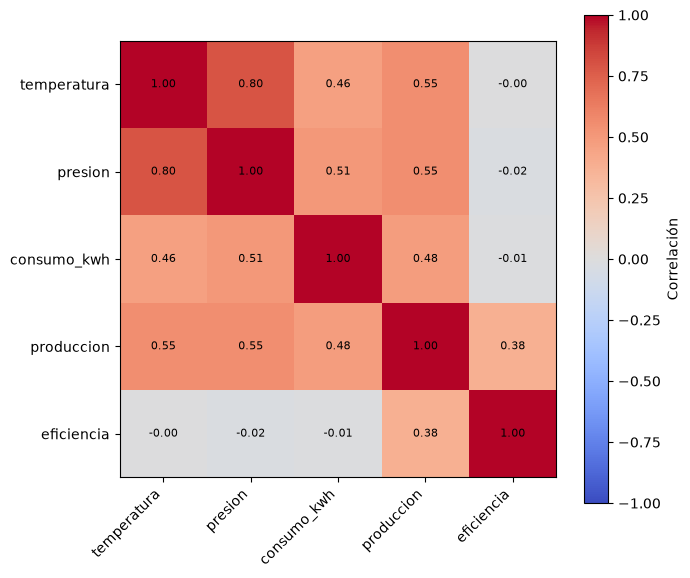

In [39]:
columnas_numericas = ["temperatura", "presion", "consumo_kwh", "produccion", "eficiencia"]
matriz_corr = df[columnas_numericas].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(matriz_corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(columnas_numericas)))
ax.set_yticks(range(len(columnas_numericas)))
ax.set_xticklabels(columnas_numericas, rotation=45, ha="right")
ax.set_yticklabels(columnas_numericas)
fig.colorbar(im, label="Correlación")

for i in range(len(columnas_numericas)):
    for j in range(len(columnas_numericas)):
        ax.text(j, i, f"{matriz_corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## Ejercicio 10 — El gráfico tiene que salir bien para la reunión de gerencia (personalización)

Retomando lo que vimos en la clase de personalización: te piden preparar el gráfico de barras del Ejercicio 3 (consumo promedio por turno), pero ahora para mostrarlo en una reunión de gerencia. Debe verse profesional.

Como mínimo, el gráfico final tiene que tener:
- Un título claro y una fuente de tamaño legible para proyectar.
- Colores consistentes (elegí una paleta prolija, no colores por defecto).
- Los valores de cada barra escritos arriba de la barra (con `ax.text()` o `ax.bar_label()`).
- Grilla suave de fondo, sin que compita visualmente con las barras.
- El gráfico guardado como imagen con `plt.savefig("consumo_por_turno.png", dpi=150, bbox_inches="tight")`.


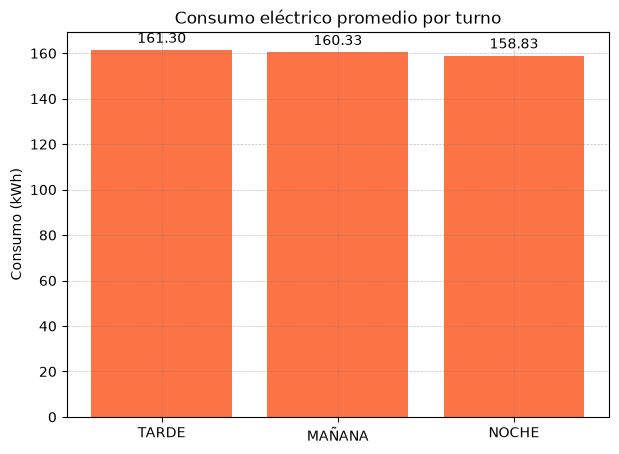

In [50]:
df["hora_del_dia"] = df.index % 24
df["turno"] = pd.cut (
    df["hora_del_dia"],
    bins=[1, 7, 15, 23],
    labels = ["NOCHE", "MAÑANA", "TARDE"]
)

consumo_por_turno = df.groupby("turno", observed=True)["consumo_kwh"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    consumo_por_turno.index, consumo_por_turno.values, color="#FC7345"
    )
ax.set_title("Consumo eléctrico promedio por turno")
ax.set_ylabel("Consumo (kWh)")

ax.bar_label(bars, fmt="%.2f", padding=3)

plt.grid(
    visible=True,      # Activa la grilla
    color='gray',      # Color de las líneas
    linestyle='--',    # Línea discontinua (guiones)
    linewidth=0.5,     # Línea delgada
    alpha=0.5          # Alta transparencia (suave)
)
plt.savefig("consumo_por_turno.png", dpi=150, bbox_inches="tight")
plt.show()

## Ejercicio 11 — Anotar el hallazgo directamente en el gráfico

Encontraste el sensor defectuoso en el Ejercicio 2, pero un gráfico sin explicación no comunica por sí solo. Retoma ese gráfico de líneas de temperatura y agrégale una anotación con flecha señalando el punto inusual, con el texto "Posible falla de sensor".

**Pistas:**
- `ax.annotate("Posible falla de sensor", xy=(15, df.loc[15, "temperatura"]), xytext=(50, 130), arrowprops=dict(facecolor="black", arrowstyle="->"))`
- Ajusta las coordenadas de `xytext` para que el texto no tape la línea.

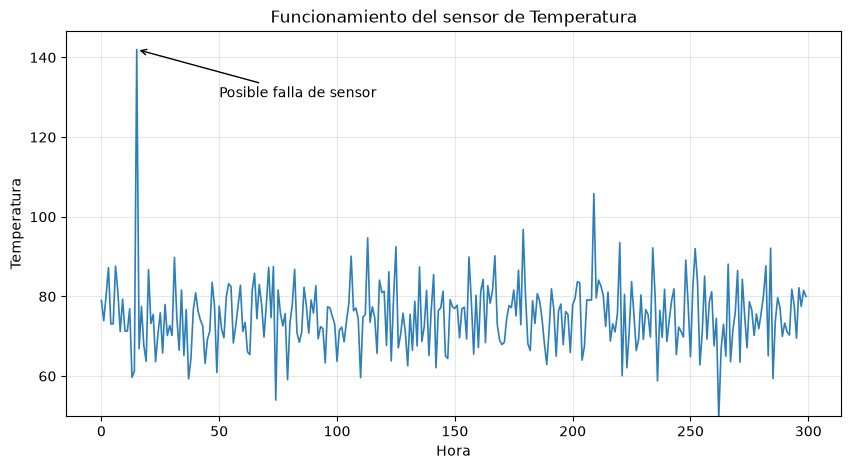

In [51]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(df.index, df["temperatura"], color="#2c7fb8", linewidth=1.2)
ax.set_title("Funcionamiento del sensor de Temperatura")
ax.set_xlabel("Hora")
ax.set_ylabel("Temperatura")
ax.set_ylim(50)
ax.grid(alpha=0.3)
ax.annotate("Posible falla de sensor", xy=(15, df.loc[15, "temperatura"]), xytext=(50, 130), arrowprops=dict(facecolor="black", arrowstyle="->"))
plt.show()